![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 9: World Models

This notebook implements **world models** on **CartPole** — collect transitions, **train an RSSM**, visualize imagined vs real trajectories, train a **LeWorldModel-style** latent predictor with **VICReg**, and learn a policy in **dream + real** environments.

> 💡 We stay on CartPole (not Atari) so the lab runs on Colab T4 while still showing an agent **dreaming** its future.

__Install packages, then run cells in order.__

# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch** — RSSM modules and rollout loops.
- **Gymnasium** — CartPole environment for transition data.
- **Matplotlib / NumPy** — Visualizing imagined trajectories.


In [5]:
!pip install -q torch gymnasium matplotlib numpy scipy


# 📥 Importing Essential Python Libraries

Imports for environment interaction and RSSM training in Part B.


In [6]:
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cpu"  # CartPole lab is lightweight on CPU
print(f"PyTorch {torch.__version__}")

PyTorch 2.11.0+cu128


__Theory first — connect definitions to the lecture slides, then move to code.__

---

## 🧠 Part A — Theory

*Reference: Ha & Schmidhuber VAE world model, RSSM, Dreamer, generative JEPA.*

### 📖 A1. Concepts

1. Formalize a world model: $s' \sim p(s' \mid s, a)$. What can $s$ contain?
2. Contrast **pixel prediction** vs **latent dynamics** for planning.
3. What is the role of the **world model** in Dreamer-style RL?

*Write below:*


#### ✍️ Your answers (A1):

1. $s$ may contain **proprioceptive state**, **observations** (pixels or features), **history**, or **latent summaries** sufficient to predict future evolution.

2. **Pixel prediction** is high-dimensional and noisy; **latent dynamics** focus on **compact state** useful for **planning**, improving **sample efficiency**.

3. In **Dreamer**, the world model enables **imagined rollouts** to train the policy **without environment interaction**, improving **sample efficiency**.

### 📖 A2. LeWorldModel

1. Why does LeWorldModel use multiple learning goals at once?
2. How does LeWorldModel learn good representations using contrastive learning?
3. How does LeWorldModel use two main loss terms to learn effectively?

*Write below:*

#### ✍️ Your answers (A2):

1. LeWorldModel uses many different learning goals (like understanding what it sees, predicting the future, and comparing different views) to help it learn versatile internal ideas (representations) that are good for many tasks. This helps it learn faster and apply what it learns more broadly.

2. LeWorldModel learns good representations by making sure that similar experiences (like an observation and what it becomes next) are close together in its internal understanding, while different experiences are far apart. This helps it create strong and clear internal representations.

3. LeWorldModel learns effectively using two simple loss terms: a prediction loss (to accurately forecast future states) and a regularizer that encourages its internal representations to be Gaussian-distributed. This simple, streamlined approach helps avoid complex loss functions and ensures stable and robust training.

---

## 💻 Part B — Programming
__Let's implement the core ideas in PyTorch.__

### 🛠️ B1. CartPole transition dataset

Collect real **CartPole-v1** transitions. These tuples train the RSSM world model in B2.

In [7]:
env = gym.make("CartPole-v1")
env.reset(seed=SEED)
transitions = []
obs, _ = env.reset()
total = 0
while total < 2000:
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    transitions.append((obs.copy(), action, next_obs.copy(), reward))
    obs = next_obs
    total += 1
    if terminated or truncated:
        obs, _ = env.reset()
env.close()

obs_all = torch.tensor(np.array([t[0] for t in transitions], dtype=np.float32), device=DEVICE)
act_all = torch.tensor([[t[1]] for t in transitions], dtype=torch.float32, device=DEVICE)
next_obs_all = torch.tensor(np.array([t[2] for t in transitions], dtype=np.float32), device=DEVICE)
rew_all = torch.tensor([t[3] for t in transitions], dtype=torch.float32, device=DEVICE)

print(f"Collected {len(transitions)} transitions.")
print(f"Sample: obs_dim={obs_all.shape[1]}, mean reward={rew_all.mean():.3f}")

Collected 2000 transitions.
Sample: obs_dim=4, mean reward=1.000


### 🛠️ B2. Tiny RSSM module + training + dream plot

Define a small **RSSM**, **fit it on B1 data**, then compare a **real vs imagined** pole-angle trajectory over 20 steps.

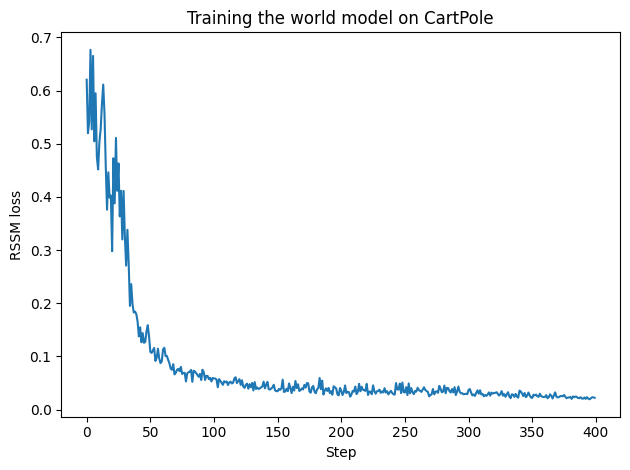

RSSM final loss: 0.0223


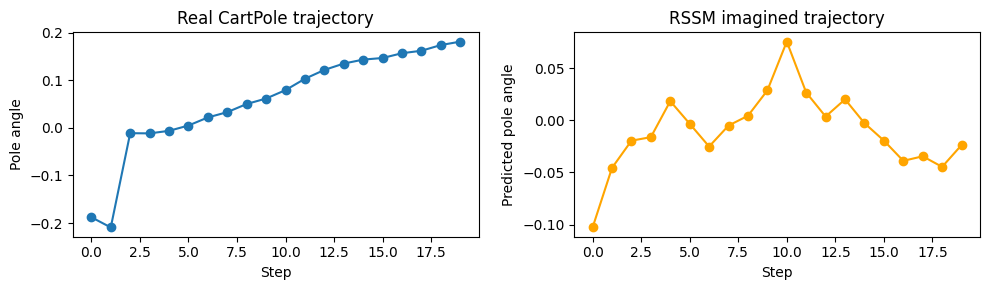

In [8]:
class MiniRSSM(nn.Module):
    def __init__(self, obs_dim, action_dim, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim + action_dim, 128), nn.ReLU(), nn.Linear(128, 2 * latent_dim),
        )
        self.prior = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(), nn.Linear(128, 2 * latent_dim),
        )
        self.deterministic = nn.GRUCell(latent_dim + action_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(2 * latent_dim, 128), nn.ReLU(), nn.Linear(128, obs_dim),
        )

    def encode(self, obs, action):
        stats = self.encoder(torch.cat([obs, action], dim=-1))
        mu, logvar = stats.chunk(2, dim=-1)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu, logvar, z

    def imagine_step(self, h, z, a):
        h = self.deterministic(torch.cat([z, a], dim=-1), h)
        stats = self.prior(h)
        mu, logvar = stats.chunk(2, dim=-1)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        obs = self.decoder(torch.cat([h, z], dim=-1))
        return h, z, obs

    def loss_on_batch(self, obs, action, next_obs):
        mu, logvar, z = self.encode(obs, action)
        h = torch.zeros(obs.size(0), self.latent_dim, device=obs.device)
        recon = self.decoder(torch.cat([h, z], dim=-1))
        recon_loss = F.mse_loss(recon, obs)
        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
        _, _, pred_next = self.imagine_step(h, z.detach(), action)
        dyn_loss = F.mse_loss(pred_next, next_obs)
        return recon_loss + 0.01 * kl + dyn_loss


def train_rssm(model, obs, act, next_obs, steps=400, batch_size=128, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()
    n = obs.size(0)
    for _ in range(steps):
        idx = torch.randint(0, n, (batch_size,))
        loss = model.loss_on_batch(obs[idx], act[idx], next_obs[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    model.eval()
    return losses


obs_dim, action_dim, latent_dim = 4, 1, 16
rssm = MiniRSSM(obs_dim, action_dim, latent_dim).to(DEVICE)
train_losses = train_rssm(rssm, obs_all, act_all, next_obs_all)

plt.plot(train_losses)
plt.xlabel("Step")
plt.ylabel("RSSM loss")
plt.title("Training the world model on CartPole")
plt.tight_layout()
plt.show()
print(f"RSSM final loss: {train_losses[-1]:.4f}")

# Dream visualization: real vs imagined pole angle over 20 steps
segment = transitions[200:220]
real_pole = [t[0][2] for t in segment]
with torch.no_grad():
    h = torch.zeros(1, latent_dim, device=DEVICE)
    o0 = torch.tensor(segment[0][0], dtype=torch.float32, device=DEVICE).unsqueeze(0)
    a0 = torch.tensor([[segment[0][1]]], dtype=torch.float32, device=DEVICE)
    _, _, z = rssm.encode(o0, a0)
    dream_pole = []
    for t in segment:
        a = torch.tensor([[t[1]]], dtype=torch.float32, device=DEVICE)
        h, z, obs_pred = rssm.imagine_step(h, z, a)
        dream_pole.append(obs_pred[0, 2].item())

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(real_pole, marker="o")
ax[0].set_title("Real CartPole trajectory")
ax[0].set_xlabel("Step")
ax[0].set_ylabel("Pole angle")
ax[1].plot(dream_pole, marker="o", color="orange")
ax[1].set_title("RSSM imagined trajectory")
ax[1].set_xlabel("Step")
ax[1].set_ylabel("Predicted pole angle")
plt.tight_layout()
plt.show()

### 🛠️ B3. LeWorldModel-style latent training (VICReg)

Train an **encoder + predictor** on CartPole observation sequences with **MSE prediction loss** and **VICReg** variance/covariance regularization (replacing mock `torch.randn` placeholders).

**Training objective:** predict next latent embeddings while VICReg stops representation collapse. This mirrors LeWorldModel's SIGReg anti-collapse idea on CartPole latents.

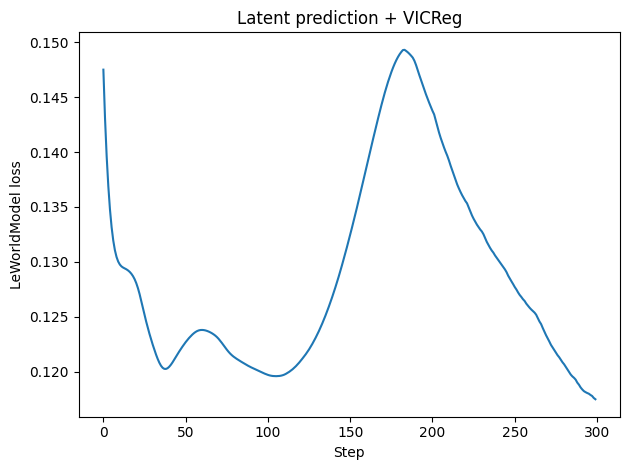

Final LeWorldModel loss: 0.1175 (pred + VICReg, no random placeholders)


In [9]:
class LatentEncoder(nn.Module):
    def __init__(self, obs_dim, emb_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 64), nn.ReLU(), nn.Linear(64, emb_dim))

    def forward(self, obs_seq):
        return self.net(obs_seq)


class LatentPredictor(nn.Module):
    def __init__(self, emb_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim + action_dim, 64), nn.ReLU(), nn.Linear(64, emb_dim),
        )

    def forward(self, emb, actions):
        return self.net(torch.cat([emb, actions], dim=-1))


def vicreg_loss(z, var_weight=1.0, cov_weight=0.1):
    """Variance + covariance regularization on batch of embeddings z: (N, D)."""
    z = z - z.mean(dim=0)
    var = F.relu(1.0 - z.var(dim=0, unbiased=False)).mean()
    cov = (z.T @ z) / max(z.size(0) - 1, 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    cov_pen = off_diag.pow(2).sum() / z.size(1)
    return var_weight * var + cov_weight * cov_pen


def build_sequences(obs, act, seq_len=12, n_seq=256):
    obs_seqs, act_seqs = [], []
    max_start = obs.size(0) - seq_len - 1
    for _ in range(n_seq):
        s = torch.randint(0, max_start, (1,)).item()
        obs_seqs.append(obs[s : s + seq_len])
        act_seqs.append(act[s : s + seq_len])
    return torch.stack(obs_seqs), torch.stack(act_seqs)


emb_dim = 32
encoder = LatentEncoder(obs_dim, emb_dim).to(DEVICE)
predictor = LatentPredictor(emb_dim, action_dim).to(DEVICE)
opt_lwm = torch.optim.Adam(list(encoder.parameters()) + list(predictor.parameters()), lr=1e-3)

obs_seqs, act_seqs = build_sequences(obs_all, act_all)
lwm_losses = []
for _ in range(300):
    emb = encoder(obs_seqs)
    pred = predictor(emb, act_seqs)
    pred_loss = F.mse_loss(pred[:, :-1], emb[:, 1:].detach())
    reg = vicreg_loss(emb.reshape(-1, emb_dim))
    loss = pred_loss + 0.1 * reg
    opt_lwm.zero_grad()
    loss.backward()
    opt_lwm.step()
    lwm_losses.append(loss.item())

plt.plot(lwm_losses)
plt.xlabel("Step")
plt.ylabel("LeWorldModel loss")
plt.title("Latent prediction + VICReg")
plt.tight_layout()
plt.show()
print(f"Final LeWorldModel loss: {lwm_losses[-1]:.4f} (pred + VICReg, no random placeholders)")

### 🛠️ B4. Policy gradient on imagined rollouts + real evaluation

Train a policy on **imagined** rollouts from the **trained RSSM**, then evaluate it back in the **real CartPole** environment.

Policy training loss: 305.5006
Mean CartPole return | random policy: 19.4
Mean CartPole return | imagined-trained policy: 48.0


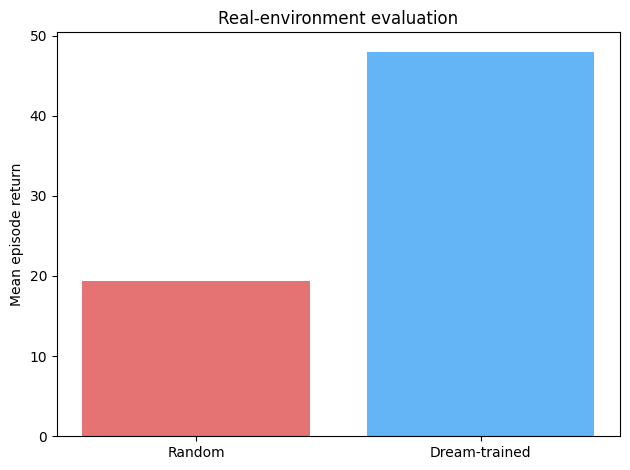

In [10]:
class LinearPolicy(nn.Module):
    def __init__(self, dim, n_actions=2):
        super().__init__()
        self.fc = nn.Linear(dim, n_actions)

    def forward(self, h):
        logits = self.fc(h)
        return torch.distributions.Categorical(logits=logits)


def imagined_reward(obs_pred):
    """Proxy reward: keep pole near upright (angle near 0)."""
    return 1.0 - obs_pred[..., 2].abs().clamp(max=1.0)


policy = LinearPolicy(rssm.latent_dim * 2).to(DEVICE)
opt_pi = torch.optim.Adam(policy.parameters(), lr=1e-2)
rssm.eval()

pg_losses = []
for step in range(100):
    h = torch.zeros(1, rssm.latent_dim, device=DEVICE)
    z = torch.zeros(1, rssm.latent_dim, device=DEVICE)
    log_probs, rewards = [], []
    for _ in range(20):
        state = torch.cat([h, z], dim=-1)
        dist = policy(state)
        a = dist.sample()
        log_probs.append(dist.log_prob(a))
        a_cont = a.float().unsqueeze(-1)
        with torch.no_grad():
            h, z, obs_pred = rssm.imagine_step(h, z, a_cont)
        rewards.append(imagined_reward(obs_pred))
    R = torch.stack(rewards).sum()
    loss = -R * torch.stack(log_probs).sum()
    opt_pi.zero_grad()
    loss.backward()
    opt_pi.step()
    pg_losses.append(loss.item())

print(f"Policy training loss: {pg_losses[-1]:.4f}")


def evaluate_in_env(policy, episodes=10):
    env = gym.make("CartPole-v1")
    returns = []
    policy.eval()
    rssm.eval()
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + ep)
        h = torch.zeros(1, rssm.latent_dim, device=DEVICE)
        o = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        a_dummy = torch.zeros(1, 1, device=DEVICE)
        with torch.no_grad():
            _, _, z = rssm.encode(o, a_dummy)
        total = 0.0
        for _ in range(500):
            state = torch.cat([h, z], dim=-1)
            action = policy(state).sample().item()
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            o = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            a_t = torch.tensor([[action]], dtype=torch.float32, device=DEVICE)
            with torch.no_grad():
                _, _, z = rssm.encode(o, a_t)
            if terminated or truncated:
                break
        returns.append(total)
    env.close()
    return float(np.mean(returns))


def evaluate_random(episodes=10):
    env = gym.make("CartPole-v1")
    returns = []
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + ep)
        total = 0.0
        for _ in range(500):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break
        returns.append(total)
    env.close()
    return float(np.mean(returns))

random_return = evaluate_random()
learned_return = evaluate_in_env(policy)

print(f"Mean CartPole return | random policy: {random_return:.1f}")
print(f"Mean CartPole return | imagined-trained policy: {learned_return:.1f}")

plt.bar(["Random", "Dream-trained"], [random_return, learned_return], color=["#e57373", "#64b5f6"])
plt.ylabel("Mean episode return")
plt.title("Real-environment evaluation")
plt.tight_layout()
plt.show()